# Batch Results: All Available Behavior Discovery Methods

Loads the capped batch comparison produced by `scripts/run_behavior_workbench_batch.py`. The table keeps successful runs and expected incompatibilities/failures together so the comparison has no hidden omissions.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name != "behavior-lab":
    ROOT = Path("/Users/joon/dev/behavior-lab")
sys.path.insert(0, str(ROOT / "src"))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

BATCH_DIR = ROOT / "outputs" / "behavior_analysis_workbench" / "batch"
RESULTS = BATCH_DIR / "batch_results.csv"
DATASETS = BATCH_DIR / "dataset_slices.json"
assert RESULTS.exists(), f"Run scripts/run_behavior_workbench_batch.py first: {RESULTS}"

## Interpretation Contract

A high score here means the embedding or segmentation is cleaner under the chosen setup. It does **not** mean the method is universally better. Always compare pose source, geometry, temporal scale, and method family before reading the score as a scientific conclusion.


## Dataset Slices

In [2]:
datasets = json.loads(DATASETS.read_text())
display(pd.DataFrame(datasets))

,name,shape,fps,has_labels,notes
0,calms21,"[1500, 14, 2]",30.0,True,{'source': '/Users/joon/dev/behavior-lab/data/...
1,subtle,"[1500, 9, 3]",20.0,False,{'source': '/Users/joon/dev/behavior-lab/data/...
2,shank3ko,"[1500, 16, 3]",30.0,True,{'source': '/Users/joon/dev/behavior-lab/data/...
3,mabe22,"[1500, 36, 2]",30.0,True,{'source': '/Users/joon/dev/behavior-lab/data/...


## Full Result Matrix

In [3]:
df = pd.read_csv(RESULTS)
cols = ["dataset", "method", "status", "n_frames", "n_clusters", "silhouette", "ari", "nmi", "num_bouts", "mean_bout_sec", "elapsed_sec", "error"]
display(df[cols].sort_values(["dataset", "method"]))

,dataset,method,status,n_frames,n_clusters,silhouette,ari,nmi,num_bouts,mean_bout_sec,elapsed_sec,error
1,calms21,B-SOiD,ok,499,4.0,0.139123,NaN,NaN,97.0,0.210005,6.256723,NaN
6,calms21,CEBRA,ok,1200,8.0,0.397582,0.142036,0.296776,31.0,1.323681,25.213179,NaN
4,calms21,SUBTLE,error,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SUBTLE route is run only on 3D slices in this ...
5,calms21,hBehaveMAE,error,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hBehaveMAE route requires MABe22 4D keypoints
3,calms21,keypoint_moseq,ok,300,18.0,NaN,0.000000,0.000000,43.0,0.247006,20.482979,NaN
0,calms21,kmeans_pca_umap,ok,1500,8.0,0.196473,0.041490,0.043173,107.0,0.529337,8.913894,NaN
2,calms21,pca_hmm_moseq_fallback,ok,1500,12.0,0.247723,0.033876,0.158667,284.0,1.486706,0.475668,NaN
22,mabe22,B-SOiD,ok,499,3.0,-0.068414,NaN,NaN,139.0,0.122298,11.823725,NaN
27,mabe22,CEBRA,ok,1200,8.0,0.606695,0.000000,0.000000,135.0,0.219623,116.451902,NaN
25,mabe22,SUBTLE,error,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SUBTLE route is run only on 3D slices in this ...


## Successful Runs Only

In [4]:
ok = df[df.status == "ok"].copy()
metric_cols = ["dataset", "method", "n_clusters", "silhouette", "ari", "nmi", "num_bouts", "mean_bout_sec", "elapsed_sec"]
display(ok[metric_cols].sort_values(["dataset", "silhouette"], ascending=[True, False]))

,dataset,method,n_clusters,silhouette,ari,nmi,num_bouts,mean_bout_sec,elapsed_sec
6,calms21,CEBRA,8.0,0.397582,0.142036,0.296776,31.0,1.323681,25.213179
2,calms21,pca_hmm_moseq_fallback,12.0,0.247723,0.033876,0.158667,284.0,1.486706,0.475668
0,calms21,kmeans_pca_umap,8.0,0.196473,0.041490,0.043173,107.0,0.529337,8.913894
1,calms21,B-SOiD,4.0,0.139123,NaN,NaN,97.0,0.210005,6.256723
3,calms21,keypoint_moseq,18.0,NaN,0.000000,0.000000,43.0,0.247006,20.482979
27,mabe22,CEBRA,8.0,0.606695,0.000000,0.000000,135.0,0.219623,116.451902
23,mabe22,pca_hmm_moseq_fallback,12.0,0.144780,0.000000,0.000000,1078.0,0.163290,1.301829
21,mabe22,kmeans_pca_umap,8.0,0.013599,0.000000,0.000000,138.0,0.265837,20.459543
22,mabe22,B-SOiD,3.0,-0.068414,NaN,NaN,139.0,0.122298,11.823725
24,mabe22,keypoint_moseq,16.0,NaN,0.000000,0.000000,55.0,0.089618,67.828287


## Heatmaps

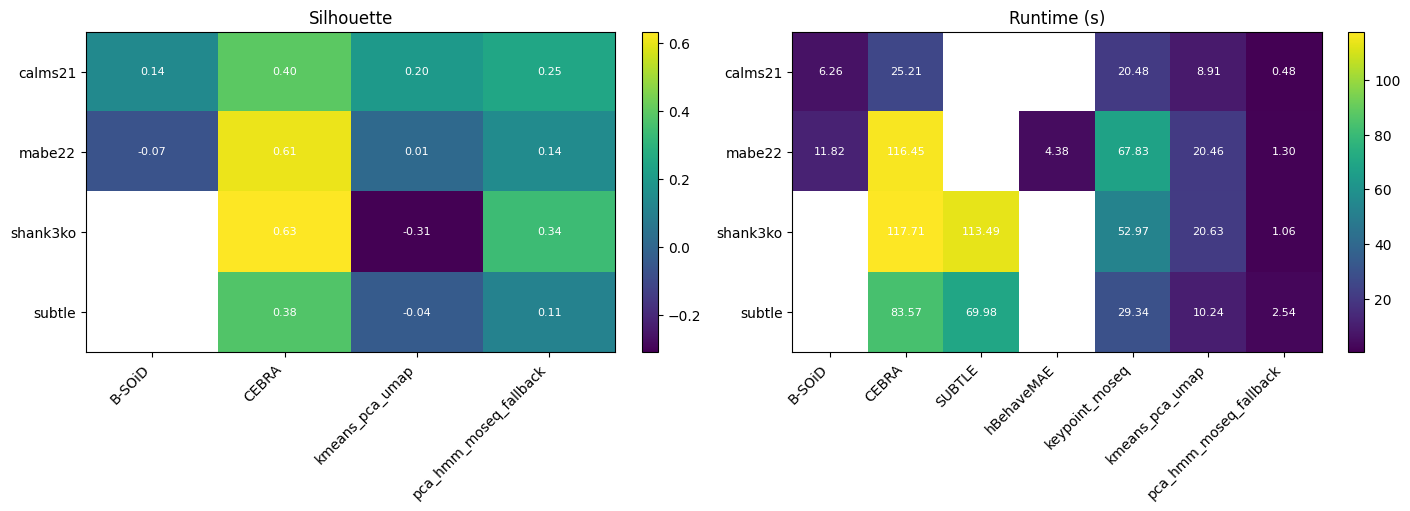

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, metric, title in zip(axes, ["silhouette", "elapsed_sec"], ["Silhouette", "Runtime (s)"]):
    pivot = ok.pivot_table(index="dataset", columns="method", values=metric, aggfunc="first")
    im = ax.imshow(pivot, aspect="auto", cmap="viridis")
    ax.set_title(title)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i, ds in enumerate(pivot.index):
        for j, method in enumerate(pivot.columns):
            val = pivot.loc[ds, method]
            if pd.notna(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(im, ax=ax)
plt.show()

## Failure / Applicability Ledger

In [6]:
errors = df[df.status != "ok"][["dataset", "method", "error"]].copy()
display(errors.sort_values(["method", "dataset"]))

,dataset,method,error
15,shank3ko,B-SOiD,B-SOiD route is run only on 2D slices in this ...
8,subtle,B-SOiD,B-SOiD route is run only on 2D slices in this ...
4,calms21,SUBTLE,SUBTLE route is run only on 3D slices in this ...
25,mabe22,SUBTLE,SUBTLE route is run only on 3D slices in this ...
5,calms21,hBehaveMAE,hBehaveMAE route requires MABe22 4D keypoints
19,shank3ko,hBehaveMAE,hBehaveMAE route requires MABe22 4D keypoints
12,subtle,hBehaveMAE,hBehaveMAE route requires MABe22 4D keypoints


## Best Method By Dataset

The table below picks the best non-`NaN` silhouette within each dataset. This is the most compact summary of the batch run, but it should still be read together with runtime and failure notes.

,dataset,method,silhouette,elapsed_sec
0,calms21,CEBRA,0.397582,25.213179
1,mabe22,CEBRA,0.606695,116.451902
2,shank3ko,CEBRA,0.632720,117.707650
3,subtle,CEBRA,0.376283,83.567881


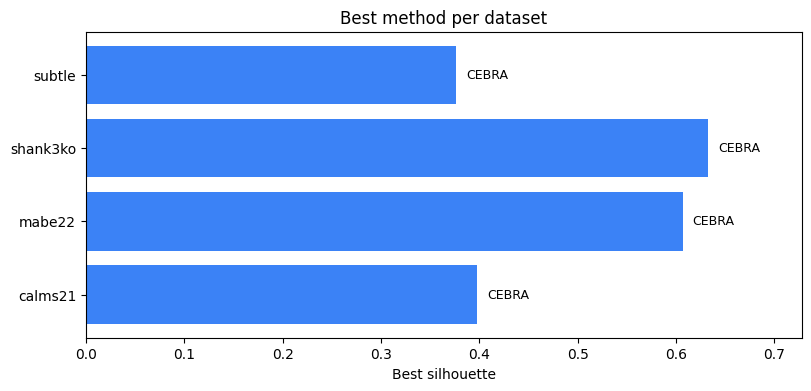

In [7]:
best_rows = []
for dataset, grp in ok.groupby('dataset'):
    valid = grp.dropna(subset=['silhouette'])
    if valid.empty:
        continue
    best = valid.loc[valid['silhouette'].idxmax()]
    best_rows.append({
        'dataset': dataset,
        'method': best['method'],
        'silhouette': float(best['silhouette']),
        'elapsed_sec': float(best['elapsed_sec']),
    })
best_df = pd.DataFrame(best_rows).sort_values('dataset')
display(best_df)

fig, ax = plt.subplots(figsize=(8, 3.8), constrained_layout=True)
ax.barh(best_df['dataset'], best_df['silhouette'], color='#3b82f6')
for i, row in enumerate(best_df.itertuples(index=False)):
    ax.text(row.silhouette + 0.01, i, row.method, va='center', fontsize=9)
ax.set_xlabel('Best silhouette')
ax.set_title('Best method per dataset')
ax.set_xlim(0, max(best_df['silhouette']) * 1.15)
plt.show()

## HTML Report Link

In [8]:
report = BATCH_DIR / "batch_report.html"
summary_png = BATCH_DIR / "batch_summary.png"
print(report)
print(summary_png)
display(HTML(f'<a href="{report}" target="_blank">Open batch HTML report</a>'))

/Users/joon/dev/behavior-lab/outputs/behavior_analysis_workbench/batch/batch_report.html
/Users/joon/dev/behavior-lab/outputs/behavior_analysis_workbench/batch/batch_summary.png


## Interpretation Notes

- CEBRA is a time-contrastive embedding method, so here it is being used as a behavior time-series representation learner rather than as a neural-only model.
- A higher silhouette means better separation in the embedding used for clustering, not a biological validity guarantee.
- `keypoint_moseq` now runs end-to-end in this environment; its silhouette can still be `NaN` when the segmentation outcome is too small or not meaningful for the metric.
- SUBTLE, B-SOiD, keypoint-MoSeq, and hBehaveMAE are not directly comparable unless their geometry and temporal assumptions are respected.
